# Batch Gradient Descent in NumPy

## 1. Retrieval

1. For $$ \hat y_i=wx_i+b $$ write the MSE loss.

> $$L(w,b)=\frac{1}{n}\sum_{i=1}^n(wx_i+b-y_i)^2$$

2. From memory, write: $$ \frac{\partial L}{\partial w}, \qquad \frac{\partial L}{\partial b} $$

> $$ \frac{\partial L}{\partial w}=\frac{1}{n}\sum_{i=1}^n2x_i(wx_i+b-y_i)$$
>
> $$ \frac{\partial L}{\partial b}=\frac{1}{n}\sum_{i=1}^n2(wx_i+b-y_i)$$

3. Write the two gradient-descent update equations.

> $$w_{new}=w_{old}-\eta \frac{\partial L}{\partial w}$$
>
> $$b_{new}=b_{old}-\eta \frac{\partial L}{\partial b}$$

4. Why is the gradient recalculated after every parameter update?

> After changing parameters, we are at a new point on the loss surface, where the gradient's direction and magnitude may be different. We therefore recalculate it before deciding the next step.

5. Why does $x_i$ appear as a multiplier in the $w$-gradient but not the $b$-gradient?

> When we are differentiating the $wx_i$ component of the $L(w,b)$ with respect to $w$, the $x_i$ becomes a multiplier in the $w$-gradient. The $b$-gradient contains no such multiplier because the $b$ term in the loss function stands alone and is not multiplied by the input value $x_i$.
>
> This makes sense conceptually as changing the slope affects predictions differently depending on the input value $x_i$, whereas changing the intercept shifts all predictions equally.

## 2.

Before coding, write one sentence for each piece of:

$$ x_{i+1}=x_i-\gamma_i((\nabla f)(x_i))^T $$

explaining:

- $x_i$

> Vector containing the model parameters on step $i$. This may be the starting model paramaters for $x_0$.

- $f$

> The objective/loss function. This is a multivariate function which depends on all model parameters.

- $\nabla f(x_i)$

> The gradient of the objective function at $x_i$. This is a vector containing the partial derivatives of $f$ with respect to each model parameter.

- $\gamma_i$

> The step-size. This scales the step-size in each gradient descent iteration.

- $x_{i+1}$

> The new model parameters after one iteration of gradient descent. 

Then translate that abstract notation into our regression problem:
$$\begin{bmatrix}w \cr b\end{bmatrix} \rarr ?$$

> $$\begin{bmatrix}w_{i+1} \cr b_{i+1}\end{bmatrix}=\begin{bmatrix}w_{i} \cr b_{i}\end{bmatrix} - \gamma_i\begin{bmatrix}\frac{\partial L}{\partial w}(x_i) \cr \frac{\partial L}{\partial b}(x_i)\end{bmatrix}$$

# 3. From equations to array operations

Use this dataset:

In [1]:
import numpy as np

rng = np.random.default_rng(42)

x = np.linspace(0, 10, 100)
noise = rng.normal(0, 2, size=x.shape)

y = 3 * x + 5 + noise

There are 100 observations and one feature.

Our model remains: $$\hat y=wx+b$$

## 4. Prediction and loss

### Exercise 1

Write these two functions yourself:
```
def predict(x, w, b):
    ...
```
Contract:
- input `x`: shape `(n,)`
- input `w`: scalar
- input `b`: scalar
- output: predictions with shape `(n,)`

Then:
```
def mse(y_true, y_pred):
    ...
```
Contract:
- both inputs shape `(n,)`
- output: **one scalar**

#### Test them first

Use:

In [2]:
test_x = np.array([1., 2., 3.])
w = 2.
b = 1.

Before running the functions, mannually predict what:
```
predict(test_x, w, b)
```
should return.

Then construct a small `test_y` yourself and calculate the expected MSE by hand before checking your function.

Then answer:

> Why should `mse()` return a scalar even though `predict()` returns an array?


### Solution 1.

In [3]:
def predict(x, w, b):
    """
    Predicts the output y_hat based on equation y_hat = w * x + b

    Args:
        x (np.array(n)): vector containing n input arguements
        w (float): weight/slope parameter
        b (float): intercept parameter
    Returns:
        y_hat (np.array(n)): vector containing predicted values
    """

    y = w * x + b
    return y

def mse(y_true, y_pred):
    """
    Calculates the mean squared error between the predicted result and the true result

    Args:
        y_true (np.array(n)): vector containing true results
        y_pred (np.array(n)): vector containing predicted values
    Returns:
        mean_squared_error (float): mean squared error between predicted and true results
    """

    residual = y_true - y_pred
    mean_squared_error =  np.mean(residual**2)
    return mean_squared_error

In [4]:
# Testing

y_hat_test = predict(test_x, w, b)
# Predicted outcome = [3 5 7]

y_test = np.array([5., 8., 11])

# Manually calculated MSE: 1/3 (2^2 + 3^2 + 4^2) = 29/3 = 9.67

mean_squared_error_test = mse(y_test, y_hat_test)
print('Test\nPredictions:', y_hat_test)
print('Predictions shape:', y_hat_test.shape)
print('MSE:', mean_squared_error_test)


Test
Predictions: [3. 5. 7.]
Predictions shape: (3,)
MSE: 9.666666666666666


`mse()` returns a scalar because the mean squared error formula calculates:
$$MSE=\frac{1}{n}\sum_{i=1}^n(\hat y_i-y)^2$$
This residual squared operation is calculated across all observations of the arrays at once and then summed to produce a single scalar value.

## 5. Implement analytical gradients

### Exercise 2.

Now write:
```
def gradients(x, y, w, b):
    ...
```

It should return:
```
dw, db
```

Use the equations you derived in the previous session:
$$\frac{\partial L}{\partial w} = \frac{1}{n}\sum_{i=1}^n2x_i(\hat{y}_i-y_i)$$
$$\frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^n2(\hat{y}_i-y_i)$$
$$\boxed{w_{i+1}=w_i-\eta \frac{\partial L}{\partial w}}$$
$$\boxed{b_{i+1}=b_i-\eta \frac{\partial L}{\partial b}}$$

#### Required checks

Using a tiny dataset:

In [5]:
x_small = np.array([1., 2.])
y_small = np.array([3., 5.])

w = 0.
b = 0.

you already calculated yesterday that:
$$\frac{\partial L}{\partial w} = -13$$
and
$$\frac{\partial L}{\partial b} = -8$$
Use that as a unit-style check

```
dw, db = gradients(...)
```
and verify that your implementation reproduces those values.

#### Required output
```
dw: ...
db: ...
Matches hand calculations: ...
```

Use an approximate numerical comparison rather than relying unnecessarily on exact floating-point equality.

In [ ]:
def gradients(x, y, w, b):
    """
    Derives the w-gradient and b-gradients

    Args:
        x (np.array(n)): vector containing n input arguements
        y (np.array(n)): vector containing true results
        w (float): weight/slope parameter
        b (float): intercept parameter
    Returns:
        dw (float): w-gradient at x
        db (float): b-gradient at x
    """

    y_predicted = w * x + b
    residual = y_predicted - y

    dw = np.mean(2 * x * residual)
    db = np.mean(2 * residual)

    return dw, db

In [7]:
# Testing

dw, db = gradients(x_small, y_small, w, b)

print('dw:', dw)
print('db:', db)
print('Matches hand calculations:', np.allclose(dw, -13) and np.allclose(db, -8))


dw: -13.0
db: -8.0
Matches hand calculations: True


Explain:

    When in your Python expression can you see the $x_i$ weighting from the mathematical $w$-gradient?

> When calculating `dw` in gradients(), each residual value is multiplied by the two times the corresponding `x` value before these products are averaged

# 6. Build batch gradient descent

### Exercise 3

Now assemble the pieces

Write:
```
def gradient_descent(x, y, learning_rate, n_iterations):
    ...
```
Start with:

In [8]:
w = 0.0
b = 0.0

learning_rate = 0.01
n_iterations = 1000

Create:

In [9]:
loss_history = []

For each iteration, your algorithm should conceptually do:
$$(w,b)$$
$$\darr$$
$$\hat y$$
$$\darr$$
$$L(w,b)$$
$$\darr$$
$$\frac{\partial L}{\partial w},~~~\frac{\partial L}{\partial b}$$
$$\darr$$
$$w_{new},~~~b_{new}$$
Then repeat.

#### Function contract

Return:
```
w, b, loss_history
```
where:
- `w` is the final scalar weight;
- `b` is the final intercept;
- `loss_hsitory` contains one loss value per iteration.

#### Required output

Print:
```
Initial loss: ...
Final loss: ...
Learned w: ...
Learned b: ...
Number of recorded losses: ...
```

Do not worry about getting exactly $w=3,b=5$. Remember that the data contain random noise.

But ask yourself whether the result is sensible given that the data were generated approximately from:
$$y=3x+5$$

In [10]:
def gradient_descent(x, y, learning_rate, n_iterations):
    """
    Completes n_iterations of gradient descent starting with w=0, b=0

    Args:
        x (np.array(n)): vector containing n input arguements
        y (np.array(n)): vector containing true results
        learning_rate (float): scalar determining scale of step size taken in each iteration
        n_iterations (int): integer denoting the number of gradient descent iterations to complete
    Returns:
        w (float): final slope gradient paramater
        b (float): final intercept parameter
        loss_history (float[]): list of scalar losses
    """
    w = 0.0
    b = 0.0

    loss_history = []

    for i in range(n_iterations):
        # Calculate and update loss value before iterating w, b
        y_prediction = predict(x, w, b)
        loss = mse(y, y_prediction)
        loss_history.append(loss)

        # Calculate w-gradient and b-gradient
        dw, db = gradients(x, y, w, b)

        # Calculate folow up w and b values
        w_new = w - learning_rate * dw
        b_new = b - learning_rate * db

        # Update w and b
        w = w_new
        b = b_new

    final_loss = mse(y, predict(x, w, b))
    loss_history.append(final_loss)

    return w, b, loss_history


In [11]:
w, b, loss_history = gradient_descent(x, y, learning_rate, n_iterations)

print('Initial loss:', loss_history[0])
print('Final loss:', loss_history[-1])
print('Learned w:', w)
print('Learned b:', b)
print('Number of recorded losses:', len(loss_history))

Initial loss: 470.6124347622935
Final loss: 2.3292028634749955
Learned w: 2.9210453126830527
Learned b: 5.286061636308319
Number of recorded losses: 1001


## 7. Visualise what the optimiser did

Make **two plots**.

First, loss against iteration:
```
x-axis: iteration
y-axis: MSE
```

Then plot:
 - the noisy observations;
 - your fitted line.

For the fitted line, use your own `predict()` functionwith the final `w,b`.

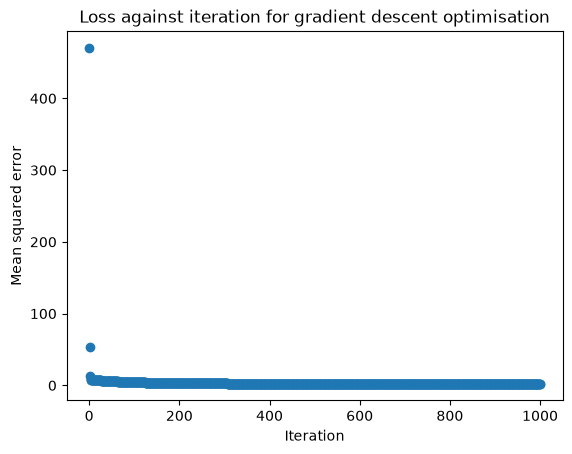

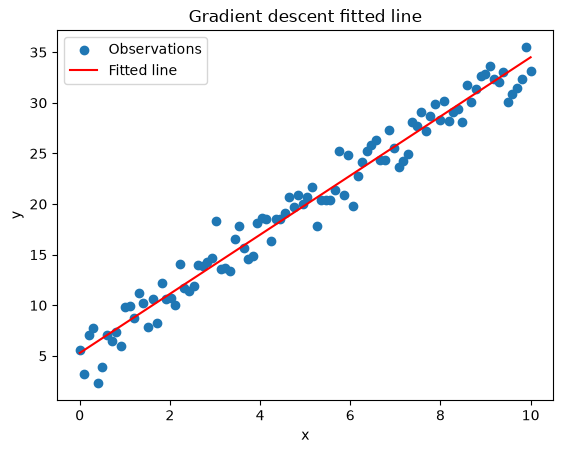

In [12]:
import matplotlib.pyplot as plt

iteration = np.arange(len(loss_history))
y_prediction = predict(x, w, b)

fig, ax = plt.subplots()

ax.scatter(iteration, loss_history)

ax.set_title('Loss against iteration for gradient descent optimisation')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean squared error')

fig, ax = plt.subplots()

ax.scatter(x, y, label='Observations')
ax.plot(x, y_prediction, 'r-', label='Fitted line')

ax.set_title('Gradient descent fitted line')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()

Answer:

1. Does the loss decrease smoothly?

> Yes. The loss decreases very rapidly during the first few iterations and then progressively flattens as the parameters approach the minimum.

2. Does it appear to flatten?

> Yes it appears to flatten after roughly 300 iterations

3. Does the fitted line visually follow the data?

> It does, it finds the parameter that minimises the mean squared vertical residuals between the predictions and observed y-values

4. What do your learned $w$ and $b$ mean geometrically?

> The observations mostly closely follow the line y = wx + b, or y = 2.92 * x + 5.29 in this particular case.

## 8. End-of-session retrieval

1. Why can one scalar \(w\) generate 100 predictions without a Python loop?

> Because numpy applies operations on entire arrays without using explicit loops - this is called vectorisation 

2. What is the shape of the residual array?

> (n,)

3. Why does mse() reduce that array to one scalar?

> mse() returns the mean of the squared error across all observations, i.e. one scalar

4. What does dw represent?

> `dw` represents $\frac{\partial L}{\partial w}$ which tells us how loss locally changes when we alter the slope $w$ while holding $b$ fixed.

5. What does db represent?


> `db` represents $\frac{\partial L}{\partial b}$ which tells us how loss locally changes when we alter the intercept $b$ while holding $w$ fixed.

6. Why is this called batch gradient descent?

> The algorithm involves calculations over the full dataset at each gradient descent step, hence the batch. Gradient descent refers to using the negative gradient of the loss function to iterate towards a local minimum value for the loss.

7. Which loop is still present in your implementation, and why?

> The for loop that runs one step of gradient descent over each of the n_iterations. This is needed because unlike when applying an operation over every element in an array using numpy, the entire array needs to be fed through the gradient descent calculation algorithm on each iteration.

8. Why must loss_history generally fall if gradient descent is working?

> Because gradient descent seeks to minimise the objective function which in this case is loss, therefore this value should fall after each iteration unless the loss has plateaued

9. Why aren't the learned parameters necessarily exactly $3$ and $5$?

> Because we added a random noise component to the y observation data meaning the data doesn't exactly follow the line $y=3x+5$ and the parameters that arise from gradient descent therefore don't match $3$ and $5$.

10. Explain your program from beginning to end without referring to individual Python syntax.

> 1. The w and b parameters are initially set to equal 0
> 2. The predicted results are calculated based on the values set for w and b using the equation $\hat y=wx+b$
> 3. The mean squared error is then evaluated by comparing these predicted values to the actual observed data, and this value is logged in a running loss history
> 4. dw and db are calculated using the equations:
> $$\frac{\partial L}{\partial w} = \frac{1}{n}\sum_{i=1}^n2x_i(\hat{y}_i-y_i)$$
> and:
> $$\frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^n2(\hat{y}_i-y_i)$$
> 5. new estimate values for w and b are caluclated using:
> $${w_{new}=w_{old}-\eta \frac{\partial L}{\partial w}}$$
> $${b_{new}=b_{old}-\eta \frac{\partial L}{\partial b}}$$
> where $\eta$ is the model learning rate. These new values for w and b replace the previous parameter values.
> 6. Return to step 2 and repeat for a desired number of iterations. The final falues for w and b are the final model parameters for the batch gradient descent algorithm.